In [ ]:
# Cell 1: Setup and streaming aggregation with multiple test functions
%env XLA_PYTHON_CLIENT_PREALLOCATE=False

import jax
jax.config.update("jax_enable_x64", False)
import jax.numpy as jnp
import pickle
import os
import matplotlib.pyplot as plt
import numpy as np

DIRS = ["./dim2_20/"]
# --- Define multiple test functions ---
f_tests = {
    "x": lambda x: x[..., 0],
    "x2": lambda x: x[..., 0]**2
}

# --- Storage for aggregated moment estimates ---
data = {DIR: {fname: {} for fname in f_tests} for DIR in DIRS}

for DIR in DIRS:
    print(f"\nProcessing DIR: {DIR}")
    for file in os.listdir(DIR):
        if file.endswith(".pkl") and file.startswith("__"):
            with open(os.path.join(DIR, file), "rb") as f:
                my_pkl = pickle.load(f)
        
            factor = my_pkl['config']['factor']
            mean = my_pkl['config']['mean']
            cov = my_pkl['config']['cov']
            num_steps = my_pkl['config'].get('num_mcmc_steps', None)
            print(f"File: {file}, factor={factor}, MCMC steps={num_steps}")

            particles = my_pkl['res'][0]  # shape (num_runs, num_particles, dim)
            print(f"Particles shape: {particles.shape}")

            # Optional: quick histogram to check distribution
            #if factor >= 3.7 and factor < 4:
            #    for j in range(particles.shape[0]):
            #        plt.hist(particles[j, ..., 0].ravel(), bins=1000)
            #        plt.title(f"{DIR} — factor={factor} - run={j}")
            #        plt.show()

            # --- Compute moment estimates for all test functions ---
            for fname, f_test in f_tests.items():
                vals = jnp.mean(f_test(particles), axis=[-1, -2])
                vals = np.asarray(vals).ravel()

                if factor not in data[DIR][fname]:
                    data[DIR][fname][factor] = []

                data[DIR][fname][factor].append(vals)

            del my_pkl  # free memory

# --- Placeholder for ground truth (to be filled later) ---
true_val = {DIR: {fname: None for fname in f_tests} for DIR in DIRS}

env: XLA_PYTHON_CLIENT_PREALLOCATE=False

Processing DIR: ./dim2_20/
File: __factor1.0000_greedy_xp.py_0401201809.pkl, factor=1.0, MCMC steps=100
Particles shape: (10000, 1, 20, 201, 2)
File: __factor3.0000_greedy_xp.py_0401202847.pkl, factor=3.0, MCMC steps=100
Particles shape: (10000, 1, 20, 601, 2)
File: __factor2.7000_greedy_xp.py_0401202531.pkl, factor=2.7, MCMC steps=100
Particles shape: (10000, 1, 20, 541, 2)
File: __factor1.8000_greedy_xp.py_0401201934.pkl, factor=1.8, MCMC steps=100
Particles shape: (10000, 1, 20, 361, 2)
File: __factor2.2000_greedy_xp.py_0401202022.pkl, factor=2.2, MCMC steps=100
Particles shape: (10000, 1, 20, 441, 2)
File: __factor3.7000_greedy_xp.py_0401203726.pkl, factor=3.7, MCMC steps=100
Particles shape: (10000, 1, 20, 741, 2)
File: __factor2.8000_greedy_xp.py_0401202634.pkl, factor=2.8, MCMC steps=100
Particles shape: (10000, 1, 20, 561, 2)
File: __factor4.0000_greedy_xp.py_0401204615.pkl, factor=4.0, MCMC steps=100
Particles shape: (10000, 1, 20, 801

(array([  45.,  689., 3047., 2989.,  888.,  648., 2889., 3758.,  972.,
         115.]),
 array([-5.64646435, -4.44229889, -3.23813367, -2.03396845, -0.82980299,
         0.37436247,  1.57852745,  2.78269291,  3.98685837,  5.19102383,
         6.39518929]),
 <BarContainer object of 10 artists>)

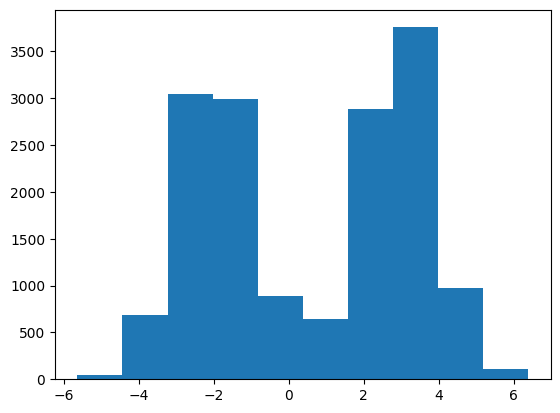

In [57]:
plt.hist(particles[3][..., 0].reshape(-1))

In [ ]:
# Cell 2: Ground-truth aggregation for multiple test functions
data_gt = {}
true_val = {}
truth_particles = {}

for DIR in DIRS:
    data_gt[DIR] = {}
    truth_particles[DIR] = {}
    true_val[DIR] = {}

    for fname in f_tests:
        data_gt[DIR][fname] = {}
        true_val[DIR][fname] = {}

    # --- Loop over files ---
    for file in os.listdir(DIR):
        if file.endswith(".pkl") and file.startswith("same_m_ground_truth"):
            with open(os.path.join(DIR, file), "rb") as f:
                my_pkl = pickle.load(f)

            factor = my_pkl['config']['factor']
            particles = my_pkl['res'][0]  # shape: (num_runs, num_particles, dim)

            # Store particles only per factor
            if factor not in truth_particles[DIR]:
                truth_particles[DIR][factor] = []
            truth_particles[DIR][factor].append(particles)

            # --- Compute moment estimates per test function ---
            for fname, f_test in f_tests.items():
                vals = jnp.mean(f_test(particles), axis=[-1, -2])
                vals = np.asarray(vals).ravel()

                if factor not in data_gt[DIR][fname]:
                    data_gt[DIR][fname][factor] = []

                data_gt[DIR][fname][factor].append(vals)

            del my_pkl

    # --- Compute true value per factor and test function ---
    for fname in f_tests:
        factor = 1.0  # always use factor = 1.0 for ground truth
        true_val[DIR][fname][factor] = np.mean(data_gt[DIR][fname][factor])

In [91]:
truth_particles[DIR][1.0][0].shape

(10000, 1, 20, 201, 2)

(array([  4.,   3.,   3.,   4.,  27.,  59.,  62., 105., 137., 123., 121.,
        158., 212., 214., 228., 162., 204., 173., 104.,  86.,  70.,  36.,
         29.,  14.,  10.,  17.,  26.,  39.,  30.,  35.,  64.,  86., 105.,
        100.,  97., 124., 175., 157., 155., 122., 117.,  91.,  55.,  20.,
         20.,  15.,  11.,   5.,   1.,   5.]),
 array([-5.058671  , -4.83501434, -4.61135721, -4.38770056, -4.1640439 ,
        -3.94038701, -3.71673012, -3.49307346, -3.26941681, -3.04575992,
        -2.82210302, -2.59844637, -2.37478948, -2.15113282, -1.92747593,
        -1.70381927, -1.48016238, -1.25650549, -1.03284883, -0.80919218,
        -0.58553505, -0.3618784 , -0.13822174,  0.08543491,  0.30909204,
         0.5327487 ,  0.75640535,  0.98006248,  1.20371914,  1.42737579,
         1.65103245,  1.87468958,  2.09834623,  2.32200289,  2.54566002,
         2.76931667,  2.99297333,  3.21662998,  3.44028664,  3.66394329,
         3.8876009 ,  4.11125755,  4.33491421,  4.55857086,  4.78222752,
 

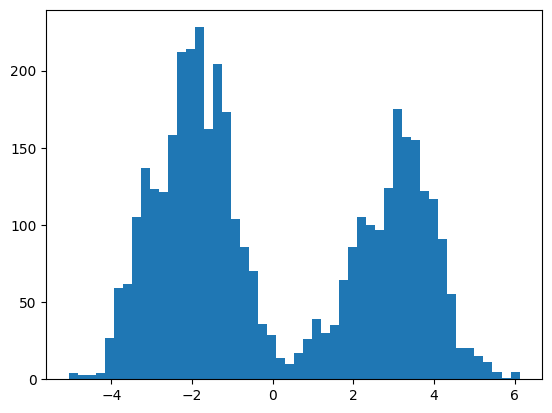

In [92]:
plt.hist(truth_particles[DIR][1.0][0][0][..., 0].reshape(-1), bins=50)

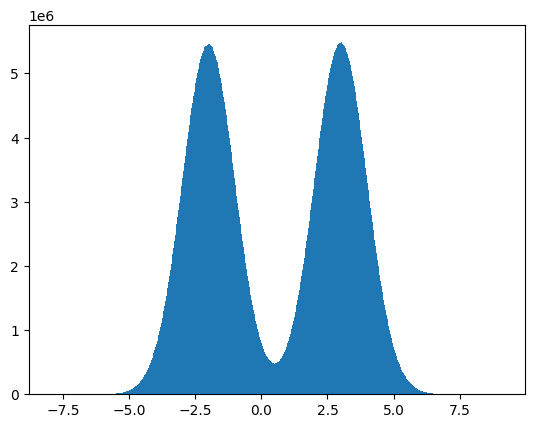

Array(0.5066858, dtype=float32)

In [93]:
plt.hist(jnp.concatenate(truth_particles[DIR][1.0], axis=0)[..., 0].reshape(-1), bins=1000)
plt.show()
jnp.concatenate(truth_particles[DIR][factor], axis=0)[..., 0].reshape(-1).mean()

In [18]:
truth_particles[DIR][factor][0]

Array([[[[[-3.4031043 ],
          [-1.2865994 ],
          [-1.2865994 ],
          ...,
          [-1.694752  ],
          [-2.4791658 ],
          [-3.1261606 ]],

         [[ 4.2690363 ],
          [ 4.2690363 ],
          [-2.0738626 ],
          ...,
          [ 2.374343  ],
          [ 2.30192   ],
          [ 4.9163094 ]],

         [[ 1.5559374 ],
          [ 1.5778869 ],
          [-1.3025659 ],
          ...,
          [ 2.0196657 ],
          [ 2.0196657 ],
          [ 2.0196657 ]],

         ...,

         [[ 2.2571404 ],
          [ 2.2571404 ],
          [ 1.895684  ],
          ...,
          [-0.8323736 ],
          [-0.8323736 ],
          [-3.9297411 ]],

         [[-0.40938723],
          [-1.3922379 ],
          [-1.3922379 ],
          ...,
          [-0.11470735],
          [ 3.5786219 ],
          [ 3.5786219 ]],

         [[-3.1055236 ],
          [-2.8076725 ],
          [-2.8076725 ],
          ...,
          [ 2.6688628 ],
          [ 3.7431774 ],
          

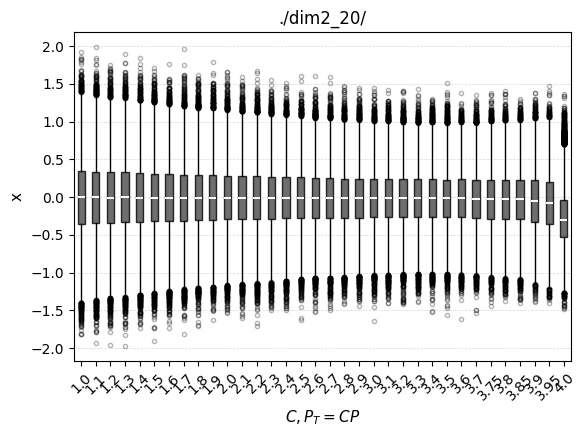

In [94]:
# Cell 2: One figure per DIR, one box per epsilon, multiple test functions

titles = {
    "./power2WFgreedy/": "Multimodal target",
}

for DIR in DIRS:
    n_tests = len(f_tests)
    fig, axes = plt.subplots(
        n_tests, 1,
        figsize=(6, 4.5*n_tests),
        sharex=True
    )

    # Ensure axes is always an array for consistent indexing
    if n_tests == 1:
        axes = np.array([axes])

    factor_list = sorted(next(iter(data[DIR].values())).keys())  # get factors from any test function

    for i_test, (fname, f_test) in enumerate(f_tests.items()):
        ax = axes[i_test]

        box_data = []

        for factor in factor_list:
            # Concatenate all runs for this test function and factor
            vals = np.concatenate(data[DIR][fname][factor], axis=0)
            # Deviation from true value (always factor=1.0)
            true_val_factor = true_val[DIR][fname][1.0]
            box_data.append(vals - true_val_factor)

        # --- Positions ---
        positions = range(len(factor_list))

        common_props = dict(linewidth=1)

        ax.boxplot(
            box_data,
            positions=positions,
            widths=0.5,
            patch_artist=True,
            boxprops=dict(facecolor="#4a4a4a", edgecolor="black", alpha=0.8, **common_props),
            medianprops=dict(color="white", linewidth=1.4),
            whiskerprops=dict(color="black", **common_props),
            capprops=dict(color="black", **common_props),
            flierprops=dict(marker='o', markersize=3, alpha=0.3)
        )

        # --- Formatting ---
        ax.set_xticks(list(positions))
        ax.set_xticklabels([str(factor) for factor in factor_list], rotation=45)
        ax.grid(axis='y', linestyle='--', linewidth=0.5, alpha=0.5)
        ax.set_ylabel(fname)  # indicate test function on y-axis
        if i_test == 0:
            ax.set_title(titles.get(DIR, DIR))

    # --- X-axis label only on bottom row ---
    axes[-1].set_xlabel(r"$C, P_T=CP$")

    plt.tight_layout()
    plt.savefig(DIR.replace("/", "_") + "_boxplots_factor.pdf", dpi=300)
    plt.show()

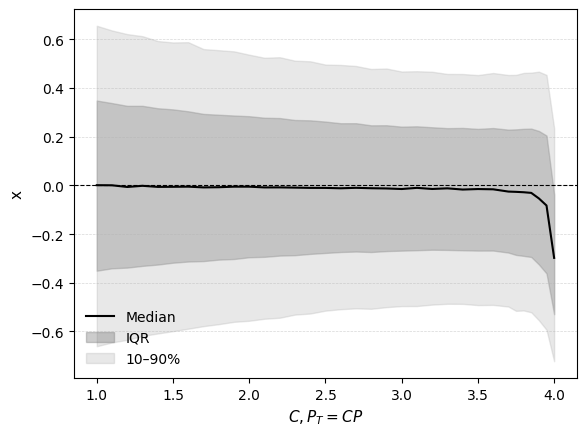

In [99]:
import matplotlib.pyplot as plt
import numpy as np

titles = {
    "./power2WFgreedy/": "Multimodal target",
}

for DIR in DIRS:
    n_tests = len(f_tests)

    fig, axes = plt.subplots(
        n_tests, 1,
        figsize=(6, 4.5*n_tests),
        sharex=True
    )

    if n_tests == 1:
        axes = np.array([axes])

    factor_list = sorted(next(iter(data[DIR].values())).keys())
    x_vals = np.array(factor_list)

    for i_test, (fname, f_test) in enumerate(f_tests.items()):
        ax = axes[i_test]

        q10, q25, q50, q75, q90 = [], [], [], [], []

        for factor in factor_list:
            vals = np.concatenate(data[DIR][fname][factor], axis=0)
            true_val_factor = true_val[DIR][fname][1.0]
            dev = vals - true_val_factor

            q10.append(np.percentile(dev, 10))
            q25.append(np.percentile(dev, 25))
            q50.append(np.percentile(dev, 50))
            q75.append(np.percentile(dev, 75))
            q90.append(np.percentile(dev, 90))

        q10 = np.array(q10)
        q25 = np.array(q25)
        q50 = np.array(q50)
        q75 = np.array(q75)
        q90 = np.array(q90)

        # --- Plot median ---
        ax.plot(x_vals, q50, color='black', linewidth=1.5, label="Median")

        # --- Interquartile band ---
        ax.fill_between(
            x_vals, q25, q75,
            color='0.5', alpha=0.4,
            label="IQR"
        )

        # --- Wider band (10–90%) ---
        ax.fill_between(
            x_vals, q10, q90,
            color='0.7', alpha=0.3,
            label="10–90%"
        )

        # --- Zero reference line ---
        ax.axhline(0, color='black', linewidth=0.8, linestyle='--')

        # --- Formatting ---
        ax.grid(axis='y', linestyle='--', linewidth=0.5, alpha=0.5)
        ax.set_ylabel(fname)

        if i_test == 0: None
#            ax.set_title(titles.get(DIR, DIR))

        # --- Legend only once ---
        if i_test == 0:
            ax.legend(frameon=False)

    axes[-1].set_xlabel(r"$C, P_T=CP$")

    plt.tight_layout()
    plt.savefig(DIR.replace("/", "_") + "_quantile_bands.pdf", dpi=300)
    plt.show()

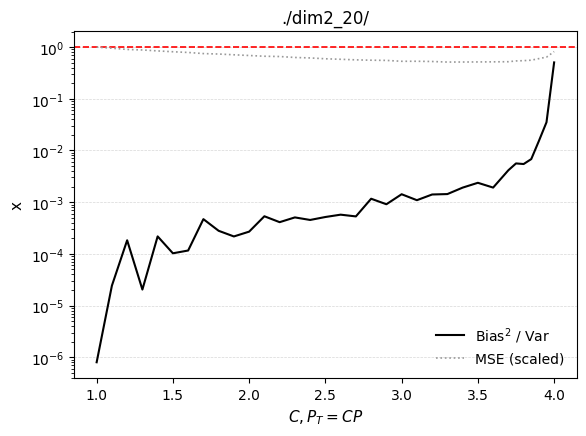

In [97]:
import matplotlib.pyplot as plt
import numpy as np

titles = {
    "./power2WFgreedy/": "Multimodal target",
}

for DIR in DIRS:
    n_tests = len(f_tests)

    fig, axes = plt.subplots(
        n_tests, 1,
        figsize=(6, 4.5*n_tests),
        sharex=True
    )

    if n_tests == 1:
        axes = np.array([axes])

    factor_list = sorted(next(iter(data[DIR].values())).keys())
    x_vals = np.array(factor_list)

    for i_test, (fname, f_test) in enumerate(f_tests.items()):
        ax = axes[i_test]

        ratio_list = []
        mse_list = []

        for factor in factor_list:
            vals = np.concatenate(data[DIR][fname][factor], axis=0)
            true_val_factor = true_val[DIR][fname][1.0]

            deviations = vals - true_val_factor

            bias = np.mean(deviations)
            variance = np.var(deviations)
            mse = bias**2 + variance

            # Avoid division by zero
            ratio = (bias**2) / (variance + 1e-16)

            ratio_list.append(ratio)
            mse_list.append(mse)

        ratio_list = np.array(ratio_list)
        mse_list = np.array(mse_list)

        # --- Plot ratio (main object) ---
        ax.plot(
            x_vals, ratio_list,
            color='black',
            linewidth=1.5,
            label=r"Bias$^2$ / Var"
        )

        # --- Horizontal reference line (transition) ---
        ax.axhline(1.0, color='red', linestyle='--', linewidth=1.2)

        # --- Optional: show MSE shape faintly (for context) ---
        ax.plot(
            x_vals, mse_list / np.max(mse_list),
            color='0.6',
            linestyle=':',
            linewidth=1.2,
            label="MSE (scaled)"
        )

        # --- Log scale (crucial!) ---
        ax.set_yscale('log')

        # --- Grid ---
        ax.grid(axis='y', linestyle='--', linewidth=0.5, alpha=0.5)

        # --- Labels ---
        ax.set_ylabel(fname)

        if i_test == 0:
            ax.set_title(titles.get(DIR, DIR))

        # --- Legend once ---
        if i_test == 0:
            ax.legend(frameon=False)

    axes[-1].set_xlabel(r"$C, P_T=CP$")

    plt.tight_layout()
    plt.savefig(DIR.replace("/", "_") + "_phase_transition.pdf", dpi=300)
    plt.show()

(array([ 14.,  42., 155., 370., 551., 471., 262., 110.,  19.,   6.]),
 array([-0.65421635, -0.41220978, -0.17020321,  0.07180339,  0.31380993,
         0.55581647,  0.79782313,  1.03982973,  1.28183627,  1.52384281,
         1.76584923]),
 <BarContainer object of 10 artists>)

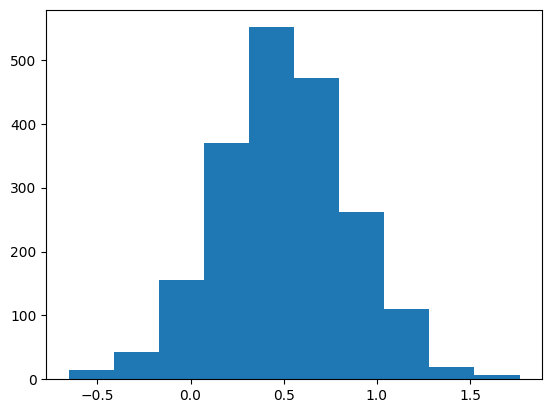

In [63]:
plt.hist(jnp.concatenate(data[DIR][fname][1.0], axis=0))

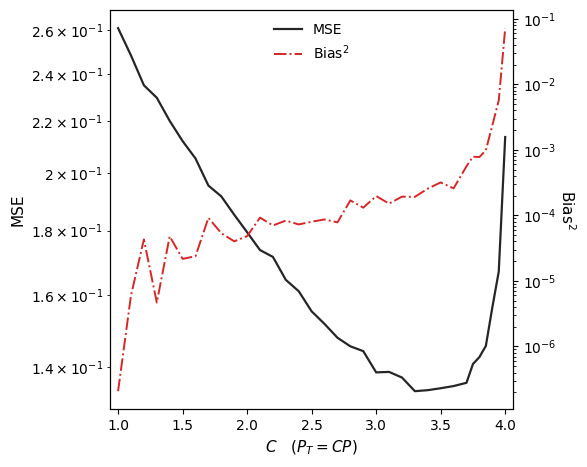

In [124]:
import matplotlib.pyplot as plt
import numpy as np

titles = {
    "./power2WFgreedy_pas_mal_dim5": "Bimodal Gaussian",
    "./power2WFgreedy_gaussian/": "Gaussian"
}

# --- Toggle here ---
use_dual_axis = True

# --- Global style (journal-like) ---
plt.rcParams.update({
    "font.size": 11,
    "axes.titlesize": 12,
    "axes.labelsize": 11,
    "legend.fontsize": 10,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "axes.linewidth": 0.8,
})

n_dirs = len(DIRS)
n_tests = len(f_tests)

fig, axes = plt.subplots(
    n_tests, n_dirs,
    figsize=(6*n_dirs, 4.8*n_tests),
    sharex='col'
)

# Ensure axes is 2D
if n_tests == 1 and n_dirs == 1:
    axes = np.array([[axes]])
elif n_tests == 1:
    axes = axes[np.newaxis, :]
elif n_dirs == 1:
    axes = axes[:, np.newaxis]

for i_test, (fname, f_test) in enumerate(f_tests.items()):
    for j_dir, DIR in enumerate(DIRS):
        ax = axes[i_test, j_dir]

        factor_list = sorted(data[DIR][fname].keys())
        x_vals = np.array(factor_list)

        mse_list = []
        bias_squared_list = []

        for factor in factor_list:
            vals = np.concatenate(data[DIR][fname][factor], axis=0)
            true_val_factor = true_val[DIR][fname][1.0]
            deviations = vals - true_val_factor

            bias_squared = np.mean(deviations)**2
            variance = np.var(deviations)
            mse = bias_squared + variance

            bias_squared_list.append(bias_squared)
            mse_list.append(mse)

        mse_list = np.array(mse_list)
        bias_squared_list = np.array(bias_squared_list)

        ax_left = ax

        # =========================
        # --- AXIS HANDLING ---
        # =========================
        if use_dual_axis:
            ax_right = ax.twinx()
        else:
            ax_right = ax_left  # same axis

        # =========================
        # --- PLOTS ---
        # =========================

        # --- MSE ---
        ax_left.plot(
            x_vals, mse_list,
            color='black',
            linestyle='-',
            linewidth=1.6,
            alpha=0.85,
            zorder=2,
            label=r"MSE"
        )

        # --- Bias^2 ---
        ax_right.plot(
            x_vals, bias_squared_list,
            color='tab:red',
            linestyle='-.',
            linewidth=1.4,
            zorder=3,
            label=r"Bias$^2$"
        )

        # --- Crosses for large C ---
        #mask = x_vals > 3.75
        #ax_left.plot(
        #    x_vals[mask], mse_list[mask],
        #    'x', color='black', markersize=6, zorder=4
        #)

        # =========================
        # --- SCALES ---
        # =========================
        ax_left.set_yscale('log')
        if use_dual_axis:
            ax_right.set_yscale('log')

        # =========================
        # --- LABELS ---
        # =========================
        if i_test == n_tests - 1:
            ax.set_xlabel(r"$C \quad (P_T = C P)$")

        if j_dir == 0:
            if use_dual_axis:
                ax_left.set_ylabel("MSE")
            else:
                ax_left.set_ylabel("MSE / Bias$^2$")
        else:
            ax_left.set_ylabel("")

        if use_dual_axis:
            ax_right.set_ylabel(r"Bias$^2$", rotation=270, labelpad=15)

        # =========================
        # --- GRID ---
        # =========================
        ax_left.grid(axis='y', linestyle='--', linewidth=0.4, alpha=0.4)

        # =========================
        # --- TEST FUNCTION LABEL ---
        # =========================
        if j_dir == 1:
            ax_to_label = ax_right if use_dual_axis else ax_left
            ax_to_label.text(
                1.1, 0.5, fname,
                transform=ax_to_label.transAxes,
                rotation=90,
                va='center', ha='center',
                fontsize=11
            )

        # =========================
        # --- LEGEND ---
        # =========================
        if i_test == 0 and j_dir == 0:
            if use_dual_axis:
                lines_left, labels_left = ax_left.get_legend_handles_labels()
                lines_right, labels_right = ax_right.get_legend_handles_labels()
                ax_left.legend(
                    lines_left + lines_right,
                    labels_left + labels_right,
                    frameon=False,
                    loc="upper center"
                )
            else:
                ax_left.legend(frameon=False, loc="upper center")

        # --- Margins ---
        ax_left.margins(x=0.02)

plt.tight_layout()
plt.savefig("MSE_toggle_axis.pdf", dpi=300)
plt.show()

<>:102: SyntaxWarning: invalid escape sequence '\h'
<>:102: SyntaxWarning: invalid escape sequence '\h'
/tmp/ipykernel_15049/833678907.py:102: SyntaxWarning: invalid escape sequence '\h'
  ax_mse.set_ylabel("MSE of $\hat{\pi}_T(f)$")


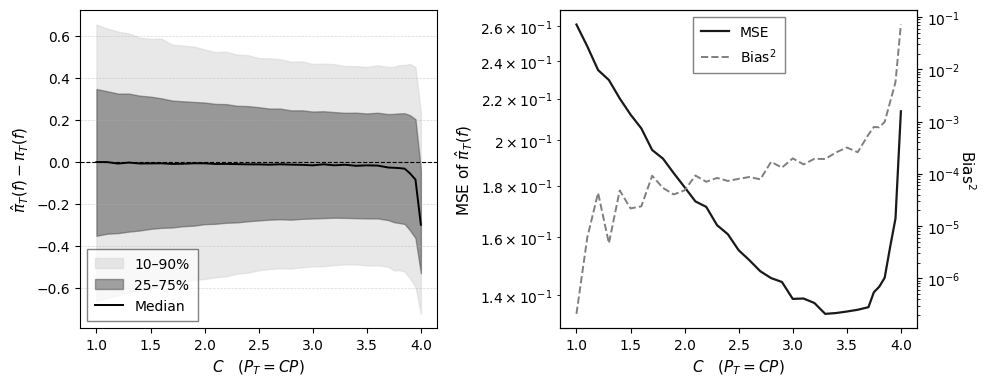

In [127]:
import matplotlib.pyplot as plt
import numpy as np

titles = {
    "./power2WFgreedy_pas_mal_dim5": "Bimodal Gaussian",
    "./power2WFgreedy_gaussian/": "Gaussian"
}

use_dual_axis = True  # for the MSE/Bias² plot

plt.rcParams.update({
    "font.size": 11,
    "axes.titlesize": 12,
    "axes.labelsize": 11,
    "legend.fontsize": 10,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "axes.linewidth": 0.8,
})

n_dirs = len(DIRS)
n_tests = len(f_tests)  # Should be 1 here for 1 row

# --- One row, two columns: left = quantiles, right = MSE/Bias² ---
fig, axes = plt.subplots(
    1, 2,
    figsize=(10, 4),
    sharex=False
)

axes = axes.flatten()
ax_quantiles, ax_mse = axes

# --- Left: Quantiles ---
for DIR in DIRS:
    fname = list(f_tests.keys())[0]  # Only one test function for simplicity
    factor_list = sorted(data[DIR][fname].keys())
    x_vals = np.array(factor_list)

    q10, q25, q50, q75, q90 = [], [], [], [], []

    for factor in factor_list:
        vals = np.concatenate(data[DIR][fname][factor], axis=0)
        true_val_factor = true_val[DIR][fname][1.0]
        dev = vals - true_val_factor

        q10.append(np.percentile(dev, 10))
        q25.append(np.percentile(dev, 25))
        q50.append(np.percentile(dev, 50))
        q75.append(np.percentile(dev, 75))
        q90.append(np.percentile(dev, 90))

    q10, q25, q50, q75, q90 = map(np.array, (q10, q25, q50, q75, q90))

    ax_quantiles.fill_between(x_vals, q10, q90, color="#d9d9d9", alpha=0.6, label="10–90%")
    ax_quantiles.fill_between(x_vals, q25, q75, color="#4a4a4a", alpha=0.5, label="25–75%")
    ax_quantiles.plot(x_vals, q50, color="black", linewidth=1.4, label="Median")

ax_quantiles.axhline(0, color="black", linestyle="--", linewidth=0.8)
ax_quantiles.set_xlabel(r"$C \quad (P_T = C P)$")
ax_quantiles.set_ylabel(r"$\hat{\pi}_T(f) - \pi_T(f)$")
ax_quantiles.grid(axis='y', linestyle='--', linewidth=0.5, alpha=0.5)
ax_quantiles.legend(frameon=True, facecolor="white", edgecolor="0.3", framealpha=0.7, fancybox=False, borderpad=0.6)
#ax_quantiles.set_title("Quantiles")

# --- Right: MSE / Bias² ---
for DIR in DIRS:
    fname = list(f_tests.keys())[0]  # Only one test function for simplicity
    factor_list = sorted(data[DIR][fname].keys())
    x_vals = np.array(factor_list)

    mse_list, bias_squared_list = [], []

    for factor in factor_list:
        vals = np.concatenate(data[DIR][fname][factor], axis=0)
        true_val_factor = true_val[DIR][fname][1.0]
        dev = vals - true_val_factor

        bias_sq = np.mean(dev)**2
        var = np.var(dev)
        mse = bias_sq + var

        mse_list.append(mse)
        bias_squared_list.append(bias_sq)

    mse_list = np.array(mse_list)
    bias_squared_list = np.array(bias_squared_list)

    ax_mse.plot(x_vals, mse_list, color="black", linewidth=1.6, alpha=0.9, label="MSE")

    if use_dual_axis:
        ax_right = ax_mse.twinx()
        ax_right.plot(x_vals, bias_squared_list, color="#7f7f7f", linestyle="--", linewidth=1.4, label=r"Bias$^2$")
        ax_right.set_ylabel(r"Bias$^2$", rotation=270, labelpad=12)
        ax_right.set_yscale("log")
    else:
        ax_mse.plot(x_vals, bias_squared_list, color="#7f7f7f", linestyle="--", linewidth=1.4, label=r"Bias$^2$")

ax_mse.set_yscale("log")
ax_mse.grid(axis='y', linestyle='--', linewidth=0.5, alpha=0.5)
ax_mse.set_xlabel(r"$C \quad (P_T = C P)$")
ax_mse.set_ylabel("MSE of $\hat{\pi}_T(f)$")
#ax_mse.set_title("MSE & Bias²")

# --- Legend on bottom left for clarity ---
handles = [ax_mse.lines[0]]
labels = ["MSE"]
if use_dual_axis:
    handles.append(ax_right.lines[0])
    labels.append(r"Bias$^2$")
ax_mse.legend(handles=handles, labels=labels, loc="upper center",
              frameon=True, facecolor="white", edgecolor="0.3",
              framealpha=0.7, fancybox=False, borderpad=0.6)

plt.tight_layout()
plt.savefig("combined_quantiles_mse_1row2col.pdf", dpi=300)
plt.show()

<>:107: SyntaxWarning: invalid escape sequence '\h'
<>:107: SyntaxWarning: invalid escape sequence '\h'
/tmp/ipykernel_15049/3789202903.py:107: SyntaxWarning: invalid escape sequence '\h'
  ax_mse.set_ylabel("MSE of $\hat{\pi}_T(f)$")


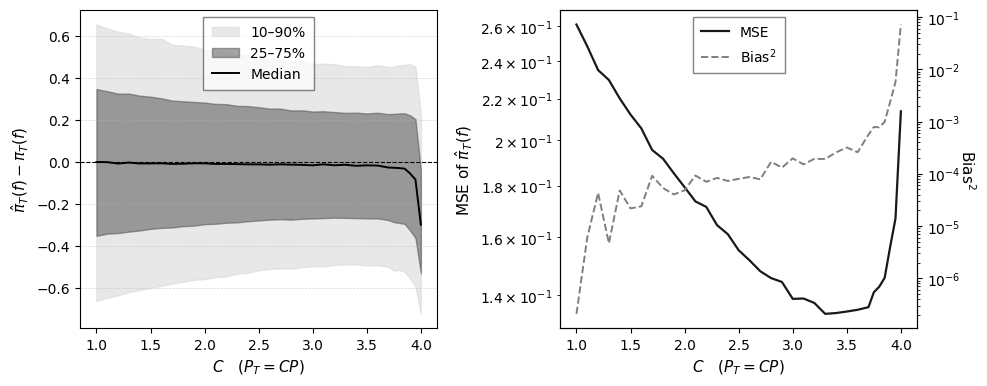

In [139]:
import matplotlib.pyplot as plt
import numpy as np

titles = {
    "./power2WFgreedy_pas_mal_dim5": "Bimodal Gaussian",
    "./power2WFgreedy_gaussian/": "Gaussian"
}

use_dual_axis = True  # for MSE/Bias² plot

plt.rcParams.update({
    "font.size": 11,
    "axes.titlesize": 12,
    "axes.labelsize": 11,
    "legend.fontsize": 10,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "axes.linewidth": 0.8,
})
f_tests = {'x': f_tests['x']}

n_tests = len(f_tests)
n_dirs = len(DIRS)  # number of datasets

# --- Create figure: rows = n_tests, cols = 2
fig, axes = plt.subplots(
    n_tests, 2,
    figsize=(10, 4 * n_tests),
    sharex=False
)

# Make sure axes is 2D
if n_tests == 1:
    axes = axes[np.newaxis, :]
for i_test, (fname, f_test) in enumerate(f_tests.items()):
    ax_quantiles = axes[i_test, 0]
    ax_mse = axes[i_test, 1]

    # --- LEFT: Quantiles ---
    for DIR in DIRS:
        factor_list = sorted(data[DIR][fname].keys())
        x_vals = np.array(factor_list)

        q10, q25, q50, q75, q90 = [], [], [], [], []

        for factor in factor_list:
            vals = np.concatenate(data[DIR][fname][factor], axis=0)
            true_val_factor = true_val[DIR][fname][1.0]
            dev = vals - true_val_factor

            q10.append(np.percentile(dev, 10))
            q25.append(np.percentile(dev, 25))
            q50.append(np.percentile(dev, 50))
            q75.append(np.percentile(dev, 75))
            q90.append(np.percentile(dev, 90))

        q10, q25, q50, q75, q90 = map(np.array, (q10, q25, q50, q75, q90))

        ax_quantiles.fill_between(x_vals, q10, q90, color="#d9d9d9", alpha=0.6, label="10–90%")
        ax_quantiles.fill_between(x_vals, q25, q75, color="#4a4a4a", alpha=0.5, label="25–75%")
        ax_quantiles.plot(x_vals, q50, color="black", linewidth=1.4, label="Median")

    ax_quantiles.axhline(0, color="black", linestyle="--", linewidth=0.8)
    ax_quantiles.set_xlabel(r"$C \quad (P_T = C P)$")
    ax_quantiles.set_ylabel(r"$\hat{\pi}_T(f) - \pi_T(f)$")
    ax_quantiles.grid(axis='y', linestyle='--', linewidth=0.5, alpha=0.5)
    #ax_quantiles.set_title(fname)
    if i_test == 0:
        ax_quantiles.legend(frameon=True, facecolor="white", edgecolor="0.3",
                            framealpha=0.7, fancybox=False, borderpad=0.6, loc="upper center")

    # --- RIGHT: MSE / Bias² ---
    for DIR in DIRS:
        factor_list = sorted(data[DIR][fname].keys())
        x_vals = np.array(factor_list)

        mse_list, bias_squared_list = [], []

        for factor in factor_list:
            vals = np.concatenate(data[DIR][fname][factor], axis=0)
            true_val_factor = true_val[DIR][fname][1.0]
            dev = vals - true_val_factor

            bias_sq = np.mean(dev)**2
            var = np.var(dev)
            mse = bias_sq + var

            mse_list.append(mse)
            bias_squared_list.append(bias_sq)

        mse_list = np.array(mse_list)
        bias_squared_list = np.array(bias_squared_list)

        ax_mse.plot(x_vals, mse_list, color="black", linewidth=1.6, alpha=0.9, label="MSE")

        if use_dual_axis:
            ax_right = ax_mse.twinx()
            ax_right.plot(x_vals, bias_squared_list, color="#7f7f7f", linestyle="--", linewidth=1.4, label=r"Bias$^2$")
            ax_right.set_ylabel(r"Bias$^2$", rotation=270, labelpad=12)
            ax_right.set_yscale("log")
        else:
            ax_mse.plot(x_vals, bias_squared_list, color="#7f7f7f", linestyle="--", linewidth=1.4, label=r"Bias$^2$")

    ax_mse.set_yscale("log")
    ax_mse.grid(axis='y', linestyle='--', linewidth=0.5, alpha=0.5)
    ax_mse.set_xlabel(r"$C \quad (P_T = C P)$")
    ax_mse.set_ylabel("MSE of $\hat{\pi}_T(f)$")

    # --- Legend only on first row ---
    if i_test == 0:
        handles = [ax_mse.lines[0]]
        labels = ["MSE"]
        if use_dual_axis:
            handles.append(ax_right.lines[0])
            labels.append(r"Bias$^2$")
        ax_mse.legend(handles=handles, labels=labels, loc="upper center",
                      frameon=True, facecolor="white", edgecolor="0.3",
                      framealpha=0.7, fancybox=False, borderpad=0.6)

plt.tight_layout()
plt.savefig("combined_quantiles_mse_multitest.pdf", dpi=300)
plt.show()

In [137]:
f_tests['x2'](np.ones(1)*3)

np.float64(9.0)